# **Objective:**

The goal of this task is to build a machine learning model that classifies whether a patient has heart disease based on clinical parameters.

In [2]:
import kagglehub
path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")

Using Colab cache for faster access to the 'heart-disease-dataset' dataset.


Dataset Preview:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Model Accuracy: 79.51%


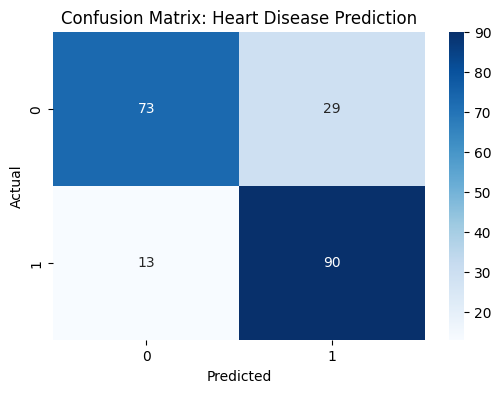

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# 1. Load the dataset (Heart Disease UCI)
url ="/kaggle/input/heart-disease-dataset/heart.csv"
df = pd.read_csv(url)

# 2. Inspect the data
print("Dataset Preview:")
print(df.head())

# 3. Prepare the Data
# 'target' is what we predict: 1 = Disease, 0 = No Disease
X = df.drop('target', axis=1)
y = df['target']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the Model (Logistic Regression)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 5. Evaluate the Model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

# 6. Visualize the Results (Confusion Matrix)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Heart Disease Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# **Explanation of Code:**

**Logistic Regression:** I chose this model because it is highly effective for binary classification (Yes/No outcomes).

**Data Splitting:** I split the data into a training set (to teach the model) and a testing set (to check its accuracy).

**Confusion Matrix:** This visualization shows how many patients were correctly identified versus how many were misclassified.